# 2 · Selección de features por modelo
## WiDS Datathon 2026 — Data Wizards

El EDA mostró mucha multicolinealidad (bloques en el heatmap). Aquí decidimos qué
features entran a cada modelo, con **dos criterios distintos según su naturaleza**:

- **Cox PH** (lineal) sufre con la colinealidad → la podamos con **VIF**.
- **RSF** (árboles) es inmune a la colinealidad → seleccionamos por **aporte real**
  (permutation importance).

Además probamos features derivadas nuevas y mostramos por qué se descartan.

In [1]:
import sys
from pathlib import Path

_SRC = next((p for p in ["src", "../src"] if (Path(p) / "wids_common.py").exists()), None)
if _SRC and _SRC not in sys.path:
    sys.path.insert(0, _SRC)

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sksurv.ensemble import RandomSurvivalForest
from lifelines import CoxPHFitter
from sksurv.util import Surv
from sksurv.metrics import (concordance_index_censored, integrated_brier_score)

from wids_common import (
    load_data, setup_style, feature_universe, make_surv, compute_vif,
    add_candidate_features, NEW_CANDIDATES, NEW_FEATURES, DROP_FEATURES,
    COX_FEATURES, RSF_FEATURES, HORIZONS, safe_times, stepfn_to_matrix,
)

PALETTE, C0, C1, C2, C3 = setup_style()
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

df_train, df_test = load_data()           # aplica engineer_features (4 derivadas)
ALL_FEATURES = feature_universe(df_train, df_test)
y = make_surv(df_train)
strat = df_train["event"].astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

RSF_PARAMS = dict(n_estimators=300, min_samples_leaf=10, max_features=0.5,
                  n_jobs=-1, random_state=42)

print(f"Universo de features: {len(ALL_FEATURES)} "
      f"({len(ALL_FEATURES) - len(NEW_FEATURES)} originales + {len(NEW_FEATURES)} derivadas)")
print(f"Eliminadas por redundancia (EDA): {DROP_FEATURES}")
print(f"Derivadas en feature engineering: {NEW_FEATURES}")

Universo de features: 33 (29 originales + 4 derivadas)
Eliminadas por redundancia (EDA): ['relative_growth_0_5h', 'log1p_area_first', 'log_area_ratio_0_5h', 'closing_speed_abs_m_per_h', 'alignment_cos']
Derivadas en feature engineering: ['estimated_hours_to_reach', 'log_dist_min', 'relative_closing_rate', 'aligned_speed']


## 2.1 Selección para Cox — paso 1: screening univariado

Ajustamos un Cox por cada feature y medimos su C-index individual. Descartamos las que
no superan **0.55** (apenas mejor que el azar): no aportan señal ni siquiera solas.

In [2]:
X_all = df_train[ALL_FEATURES].astype(float)
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_all), columns=ALL_FEATURES)

univ = []
for f in ALL_FEATURES:
    d = pd.DataFrame({f: X_scaled[f].values,
                      "time_to_hit_hours": df_train["time_to_hit_hours"].values,
                      "event": df_train["event"].values})
    cph = CoxPHFitter(penalizer=0.1).fit(d, "time_to_hit_hours", "event")
    risk = cph.predict_partial_hazard(d).values
    c = concordance_index_censored(y["event"], y["time_to_hit_hours"], risk)[0]
    univ.append({"feature": f, "C_univ": c})
univ = pd.DataFrame(univ).sort_values("C_univ", ascending=False)

candidatas = univ[univ["C_univ"] >= 0.55]["feature"].tolist()
print(f"Candidatas con C_univ >= 0.55: {len(candidatas)} de {len(ALL_FEATURES)}")
print(univ.head(8).to_string(index=False))

Candidatas con C_univ >= 0.55: 21 de 33
                     feature   C_univ
            dist_min_ci_0_5h 0.909490
                log_dist_min 0.909490
         num_perimeters_0_5h 0.717663
          dt_first_last_0_5h 0.703544
               alignment_abs 0.699238
low_temporal_resolution_0_5h 0.694684
               aligned_speed 0.620321
     centroid_displacement_m 0.619162


## 2.2 Selección para Cox — paso 2: VIF iterativo

Entre las candidatas eliminamos colinealidad: quitamos iterativamente la feature de
mayor VIF mientras supere 5. (Si compiten `dist_min_ci_0_5h` y su log, conservamos la
distancia cruda por interpretabilidad.) Los VIF iniciales son enormes — síntoma de la
redundancia que vimos en el heatmap.

In [3]:
cox_set = candidatas[:]
removed = []
while len(cox_set) > 1:
    vif = compute_vif(X_scaled[cox_set])
    worst, worst_vif = vif.index[0], vif.iloc[0]
    if worst_vif <= 5:
        break
    if worst == "dist_min_ci_0_5h" and "log_dist_min" in cox_set:
        worst = "log_dist_min"
    removed.append((worst, worst_vif))
    cox_set.remove(worst)

print(f"Cox: {len(candidatas)} candidatas -> {len(cox_set)} finales (VIF <= 5)")
print("\nEliminadas por VIF alto (redundantes):")
for f, v in removed[:6]:
    print(f"  {f:<28} VIF = {v:,.0f}")
print(f"\nSet Cox final ({len(cox_set)}): {cox_set}")
print(f"Coincide con COX_FEATURES (wids_common): {sorted(cox_set) == sorted(COX_FEATURES)}")

Cox: 21 candidatas -> 11 finales (VIF <= 5)

Eliminadas por VIF alto (redundantes):
  area_growth_rate_ha_per_h    VIF = 32,024
  radial_growth_m              VIF = 2,558
  centroid_displacement_m      VIF = 201
  radial_growth_rate_m_per_h   VIF = 139
  area_growth_rel_0_5h         VIF = 46
  centroid_speed_m_per_h       VIF = 22

Set Cox final (11): ['dist_min_ci_0_5h', 'log_dist_min', 'dt_first_last_0_5h', 'alignment_abs', 'aligned_speed', 'spread_bearing_cos', 'log1p_growth', 'dist_fit_r2_0_5h', 'spread_bearing_sin', 'area_first_ha', 'dist_std_ci_0_5h']
Coincide con COX_FEATURES (wids_common): True


El screening + VIF deja **11 features** (las que `wids_common.COX_FEATURES` expone para
que el modelo Cox las consuma). La poda no solo simplifica: estabiliza el modelo, como
se ve abajo en la comparación de escenarios.

## 2.3 Selección para RSF — permutation importance

El RSF no necesita VIF. Entrenamos sobre las 33 features y medimos cuánto cae el
C-index al permutar cada una. Las que no mueven la aguja (importancia y desviación = 0)
se eliminan: no se usan en ningún árbol.

In [4]:
rsf = RandomSurvivalForest(**RSF_PARAMS)
rsf.fit(X_all.values, y)
perm = permutation_importance(
    rsf, X_all.values, y, n_repeats=15, random_state=42, n_jobs=-1,
    scoring=lambda est, X, yy: concordance_index_censored(
        yy["event"], yy["time_to_hit_hours"], est.predict(X))[0],
)
imp = pd.DataFrame({"feature": ALL_FEATURES, "imp": perm.importances_mean,
                    "std": perm.importances_std}).sort_values("imp", ascending=False)

rsf_set = imp[(imp["imp"] > 0) | (imp["std"] > 0)]["feature"].tolist()
eliminadas_rsf = [f for f in ALL_FEATURES if f not in rsf_set]
print(f"RSF: {len(ALL_FEATURES)} -> {len(rsf_set)} features (importancia > 0)")
print(f"Coincide con RSF_FEATURES (wids_common): {sorted(rsf_set) == sorted(RSF_FEATURES)}")
print(f"\nEliminadas ({len(eliminadas_rsf)}): {eliminadas_rsf}")
print("\nTop 6 por importancia:")
print(imp.head(6).to_string(index=False))

RSF: 33 -> 24 features (importancia > 0)
Coincide con RSF_FEATURES (wids_common): True

Eliminadas (9): ['dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'along_track_speed', 'estimated_hours_to_reach', 'relative_closing_rate']

Top 6 por importancia:
            feature      imp      std
   dist_min_ci_0_5h 0.072093 0.009527
       log_dist_min 0.064817 0.009206
num_perimeters_0_5h 0.007486 0.003941
 dt_first_last_0_5h 0.004792 0.002838
      area_first_ha 0.002843 0.001774
   event_start_hour 0.001143 0.000951


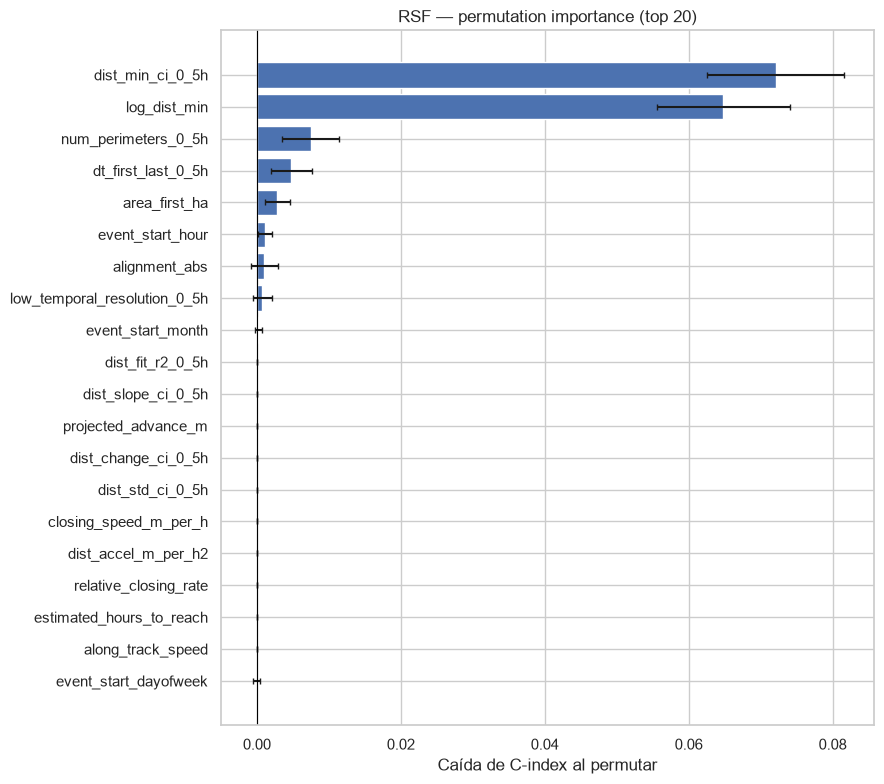

In [5]:
fig, ax = plt.subplots(figsize=(9, 8))
top = imp.head(20)[::-1]
ax.barh(top["feature"], top["imp"], xerr=top["std"],
        color=[C0 if v > 0 else C1 for v in top["imp"]], edgecolor="white", capsize=2)
ax.axvline(0, color="black", lw=0.8)
ax.set(title="RSF — permutation importance (top 20)", xlabel="Caída de C-index al permutar")
plt.tight_layout()
plt.savefig(FIG_DIR / "14_rsf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

Las dos features de distancia (`dist_min_ci_0_5h`, `log_dist_min`) concentran la mayor
parte de la señal — coherente con la separación perfecta a 5 km del EDA.

## 2.4 ¿Cuánto importa la selección? Comparación de escenarios

Comparamos C-index (CV 5-fold) con todas las features vs el set seleccionado, para cada
modelo. La diferencia entre Cox y RSF es la lección central.

Modelo    Features      C    std
   Cox  Todas (33) 0.8655 0.0986
   Cox Selec. (11) 0.9219 0.0204
   RSF  Todas (33) 0.9485 0.0061
   RSF Selec. (24) 0.9481 0.0049


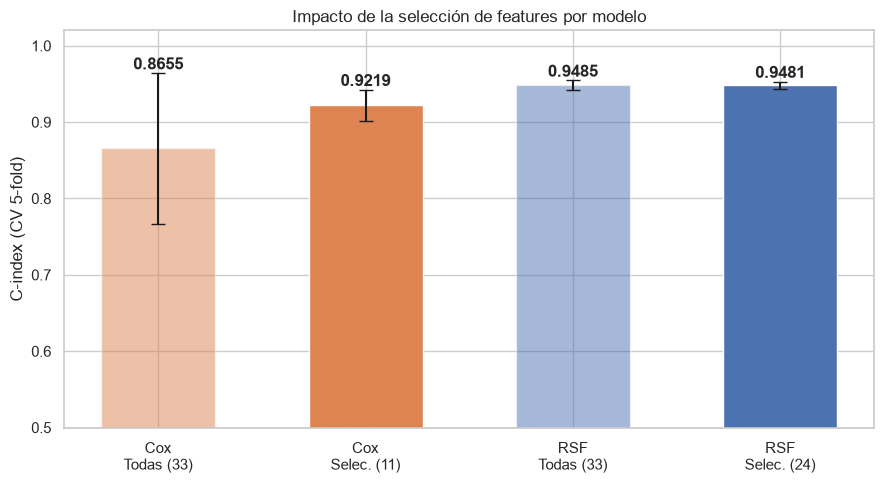

In [6]:
def cv_cindex_rsf(feats):
    sc = []
    for tr, va in cv.split(df_train, strat):
        m = RandomSurvivalForest(**RSF_PARAMS)
        m.fit(df_train[feats].astype(float).values[tr], y[tr])
        r = m.predict(df_train[feats].astype(float).values[va])
        sc.append(concordance_index_censored(y[va]["event"], y[va]["time_to_hit_hours"], r)[0])
    return np.mean(sc), np.std(sc)


def cv_cindex_cox(feats, penalizer):
    sc = []
    for tr, va in cv.split(df_train, strat):
        s = StandardScaler()
        Xtr = pd.DataFrame(s.fit_transform(df_train[feats].iloc[tr]), columns=feats)
        Xtr["time_to_hit_hours"] = df_train["time_to_hit_hours"].values[tr]
        Xtr["event"] = df_train["event"].values[tr]
        Xva = pd.DataFrame(s.transform(df_train[feats].iloc[va]), columns=feats)
        m = CoxPHFitter(penalizer=penalizer).fit(Xtr, "time_to_hit_hours", "event")
        risk = m.predict_partial_hazard(Xva).values
        sc.append(concordance_index_censored(y[va]["event"], y[va]["time_to_hit_hours"], risk)[0])
    return np.mean(sc), np.std(sc)


escenarios = pd.DataFrame([
    {"Modelo": "Cox", "Features": f"Todas ({len(ALL_FEATURES)})", **dict(zip(["C", "std"], cv_cindex_cox(ALL_FEATURES, 0.05)))},
    {"Modelo": "Cox", "Features": f"Selec. ({len(cox_set)})", **dict(zip(["C", "std"], cv_cindex_cox(cox_set, 0.05)))},
    {"Modelo": "RSF", "Features": f"Todas ({len(ALL_FEATURES)})", **dict(zip(["C", "std"], cv_cindex_rsf(ALL_FEATURES)))},
    {"Modelo": "RSF", "Features": f"Selec. ({len(rsf_set)})", **dict(zip(["C", "std"], cv_cindex_rsf(rsf_set)))},
])
print(escenarios.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = [C1, C1, C0, C0]
alphas = [0.5, 1.0, 0.5, 1.0]
for i, row in escenarios.iterrows():
    ax.bar(i, row["C"], yerr=row["std"], capsize=5, color=colors[i], alpha=alphas[i],
           edgecolor="white", width=0.55)
    ax.text(i, row["C"] + row["std"] + 0.005, f"{row['C']:.4f}", ha="center", fontweight="bold")
ax.set_xticks(range(4))
ax.set_xticklabels([f"{r['Modelo']}\n{r['Features']}" for _, r in escenarios.iterrows()])
ax.set(ylim=(0.5, 1.02), ylabel="C-index (CV 5-fold)", title="Impacto de la selección de features por modelo")
ax.axhline(0.5, color="gray", ls="--", lw=1)
plt.tight_layout()
plt.savefig(FIG_DIR / "21_feature_selection_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**La lección:** en el **Cox**, podar de 33 a 11 estabiliza el modelo (la varianza entre
folds cae drásticamente); en el **RSF**, pasar de 33 a 24 deja el C-index prácticamente
igual — la selección es cosmética porque los árboles ya ignoran lo irrelevante.

## 2.5 Colinealidad y logs: por qué afecta solo al Cox

Para aislar el efecto de la colinealidad, comparamos Cox y RSF sobre la **data original
cruda** (sin nuestro feature engineering) en tres escenarios: con todas las features
(colineales), conservando solo una log representante (eliminando 14 correlacionadas a
|Spearman| > 0.8), y eliminando las logs.

In [7]:
# Columnas originales del dataset (sin ids/target ni nuestras 4 derivadas).
NONFEAT = ["event_id", "time_to_hit_hours", "event"] + NEW_FEATURES
ORIG = [c for c in df_train.columns if c not in NONFEAT]
LOGS = [c for c in ORIG if c.startswith("log")]

corr = df_train[ORIG].corr(method="spearman").abs()
correl_con_logs = sorted({
    p for lg in LOGS for p in corr[lg].drop(index=lg).index
    if corr.loc[p, lg] > 0.8 and p not in LOGS
})

SCEN = {
    "Original": ORIG,
    "Con logs (-corr)": [c for c in ORIG if c not in correl_con_logs],
    "Sin logs": [c for c in ORIG if c not in LOGS],
}
for n, fs in SCEN.items():
    print(f"  {n:18s}: {len(fs)} features")

  Original          : 34 features
  Con logs (-corr)  : 20 features
  Sin logs          : 31 features


In [8]:
def eval_scen(feats, model):
    cs, ibss = [], []
    for tr, va in cv.split(df_train, strat):
        df_tr, df_va = df_train.iloc[tr], df_train.iloc[va]
        y_tr, y_va = y[tr], y[va]
        tf = safe_times(y_tr, y_va)
        Xtr, Xva = df_tr[feats].astype(float), df_va[feats].astype(float)
        if model == "Cox":
            s = StandardScaler()
            Xtr_s = pd.DataFrame(s.fit_transform(Xtr), columns=feats)
            Xtr_s["time_to_hit_hours"] = df_tr["time_to_hit_hours"].values
            Xtr_s["event"] = df_tr["event"].values
            Xva_s = pd.DataFrame(s.transform(Xva), columns=feats)
            m = CoxPHFitter(penalizer=0.05).fit(Xtr_s, "time_to_hit_hours", "event")  # L2 para estabilizar
            risk = 1 - m.predict_survival_function(Xva_s, times=[max(tf)]).T.values[:, 0]
            sf = m.predict_survival_function(Xva_s, times=tf).T.values
        else:
            m = RandomSurvivalForest(**RSF_PARAMS)
            m.fit(Xtr.values, y_tr)
            risk = m.predict(Xva.values)
            sf = stepfn_to_matrix(m.predict_survival_function(Xva.values), tf)
        cs.append(concordance_index_censored(y_va["event"], y_va["time_to_hit_hours"], risk)[0])
        ibss.append(integrated_brier_score(y_tr, y_va, sf, tf))
    return np.mean(cs), np.std(cs), np.mean(ibss)


rows = []
for model in ["Cox", "RSF"]:
    for scen, feats in SCEN.items():
        c, cstd, ibs = eval_scen(feats, model)
        rows.append({"Modelo": model, "Escenario": scen, "n": len(feats),
                     "C": c, "C_std": cstd, "IBS": ibs})
logscen = pd.DataFrame(rows)
print(logscen.round(4).to_string(index=False))

Modelo        Escenario  n      C  C_std    IBS
   Cox         Original 34 0.8155 0.0859 0.1450
   Cox Con logs (-corr) 20 0.8387 0.0499 0.1505
   Cox         Sin logs 31 0.8097 0.0915 0.1437
   RSF         Original 34 0.9479 0.0092 0.0349
   RSF Con logs (-corr) 20 0.9488 0.0095 0.0358
   RSF         Sin logs 31 0.9470 0.0095 0.0356


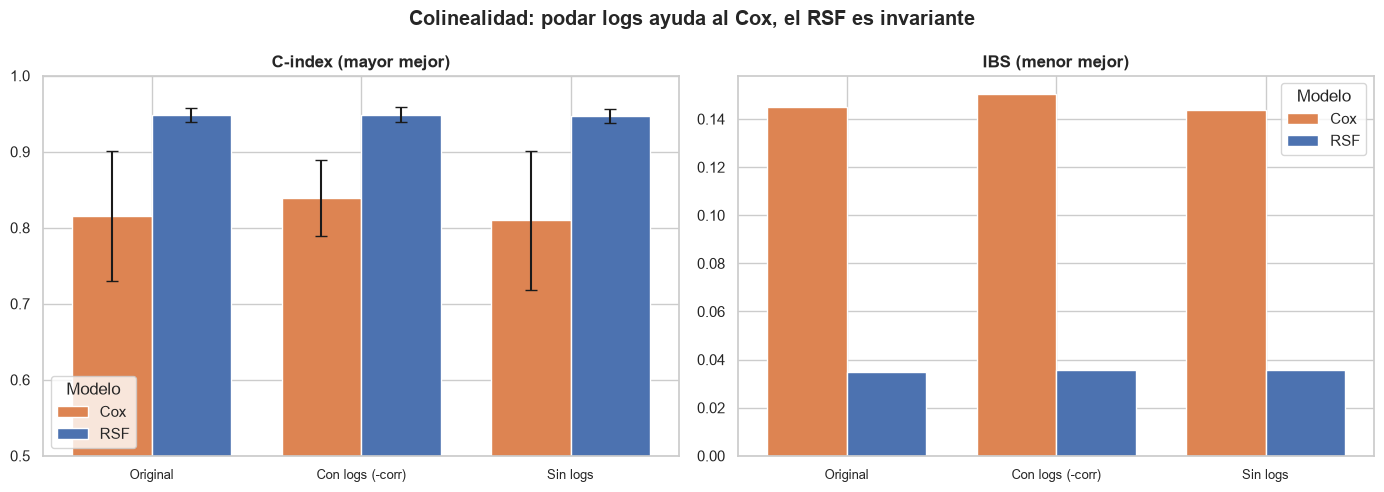

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scen_order = list(SCEN)
x = np.arange(len(scen_order))
w = 0.38
for k, model in enumerate(["Cox", "RSF"]):
    sub = logscen[logscen["Modelo"] == model].set_index("Escenario").loc[scen_order]
    axes[0].bar(x + (k - 0.5) * w, sub["C"], w, yerr=sub["C_std"], capsize=4,
                color=[C1, C0][k], edgecolor="white", label=model)
    axes[1].bar(x + (k - 0.5) * w, sub["IBS"], w, color=[C1, C0][k], edgecolor="white", label=model)
for ax, title, lo in [(axes[0], "C-index (mayor mejor)", 0.5), (axes[1], "IBS (menor mejor)", 0)]:
    ax.set_xticks(x); ax.set_xticklabels(scen_order, fontsize=9)
    ax.set_title(title, fontweight="bold"); ax.legend(title="Modelo")
axes[0].set_ylim(0.5, 1.0)
plt.suptitle("Colinealidad: podar logs ayuda al Cox, el RSF es invariante", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "22_log_scenarios_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

El **Cox mejora** al quedarse con una log representante (sube el C-index y baja la
varianza entre folds); el **RSF no se inmuta** en los tres escenarios. Confirma que el
problema de la colinealidad —y el beneficio de podarla— es específico del modelo lineal.

## 2.6 Features nuevas probadas y descartadas

Probamos 10 features derivadas (ratios y cinemáticas). Como el RSF puede explotar
no-linealidades que el Cox no ve, las evaluamos agregándolas al RSF base (24) y medimos
si mejoran el C-index y si el modelo realmente las usa.

RSF base (24)      : C = 0.9481 ± 0.0049
RSF aumentado (34) : C = 0.9517 ± 0.0080
ΔC = +0.0036  (dentro del ruido)


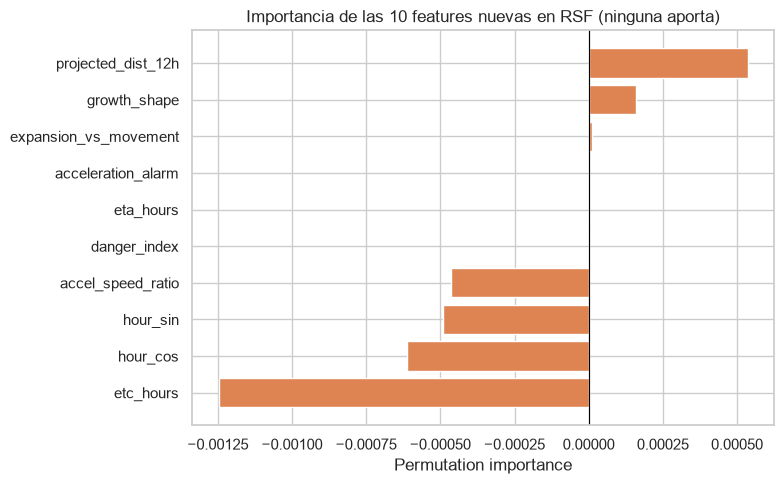

In [10]:
df_aug = add_candidate_features(df_train)
RSF_AUG = RSF_FEATURES + NEW_CANDIDATES

base_c = cv_cindex_rsf(RSF_FEATURES)
aug_c = []
for tr, va in cv.split(df_train, strat):
    m = RandomSurvivalForest(**RSF_PARAMS)
    m.fit(df_aug[RSF_AUG].astype(float).values[tr], y[tr])
    r = m.predict(df_aug[RSF_AUG].astype(float).values[va])
    aug_c.append(concordance_index_censored(y[va]["event"], y[va]["time_to_hit_hours"], r)[0])
aug_c = (np.mean(aug_c), np.std(aug_c))

print(f"RSF base (24)      : C = {base_c[0]:.4f} ± {base_c[1]:.4f}")
print(f"RSF aumentado (34) : C = {aug_c[0]:.4f} ± {aug_c[1]:.4f}")
print(f"ΔC = {aug_c[0] - base_c[0]:+.4f}  (dentro del ruido)")

# Permutation importance: ¿usa el RSF las nuevas?
m_aug = RandomSurvivalForest(**RSF_PARAMS)
m_aug.fit(df_aug[RSF_AUG].astype(float).values, y)
pi = permutation_importance(m_aug, df_aug[RSF_AUG].astype(float).values, y,
                            n_repeats=15, random_state=42, n_jobs=-1)
imp_new = pd.Series(pi.importances_mean, index=RSF_AUG)[NEW_CANDIDATES].sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_new.index, imp_new.values, color=C1, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Importancia de las 10 features nuevas en RSF (ninguna aporta)",
       xlabel="Permutation importance")
plt.tight_layout()
plt.savefig(FIG_DIR / "31_new_features_rsf.png", dpi=150, bbox_inches="tight")
plt.show()

Agregar las 10 nuevas sube el C-index apenas +0.004 (menor que la desviación entre
folds) y la permutation importance las deja todas cerca de cero: el RSF no las usa.
**Conclusión: nos quedamos con las features base.** `dist_min` / `log_dist_min` ya
capturan toda la señal de distancia.

## Resumen

- **Cox PH → 11 features** (VIF ≤ 5). La poda es obligatoria: estabiliza el modelo.
- **RSF → 24 features** (importancia > 0). La poda es opcional: mismo C-index, modelo
  más limpio.
- La colinealidad afecta solo al Cox; el RSF es invariante.
- Las 10 features nuevas no aportan y se descartan.

Estos sets quedan fijados en `wids_common` (`COX_FEATURES`, `RSF_FEATURES`) y los
consumen los notebooks de modelado.